In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
# Load the dataset
data = pd.read_csv('300EEE_class_temp_dataset.csv')
data.head()

,Date,timeFrame,gridePoints,Humidity (%),roomHeight (cm),roomWidth(cm),roomLength(cm),num_students,windowsOpen,fansWorking,temperature (oC)
0,6/3/2026,MORNING,A1,70.0,379,760,1516,27,15,0,31.4
1,6/3/2026,MORNING,A2,71.0,379,760,1516,27,15,0,31.4
2,6/3/2026,MORNING,A3,71.0,379,760,1516,27,15,0,31.6
3,6/3/2026,MORNING,A4,71.0,379,760,1516,27,15,0,31.6
4,6/3/2026,MORNING,B1,71.0,379,760,1516,27,15,0,31.4


In [13]:
# Check for missing values
print("Missing values:\n", data.isnull().sum())

# Drop rows with missing values (if any)
data = data.dropna()

# Output basic information about the dataset
data.info()

Missing values:
 Date                0
timeFrame           0
gridePoints         0
Humidity (%)        0
roomHeight (cm)     0
roomWidth(cm)       0
roomLength(cm)      0
num_students        0
windowsOpen         0
fansWorking         0
temperature (oC)    0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1008 entries, 0 to 1007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1008 non-null   object 
 1   timeFrame         1008 non-null   object 
 2   gridePoints       1008 non-null   object 
 3   Humidity (%)      1008 non-null   float64
 4   roomHeight (cm)   1008 non-null   int64  
 5   roomWidth(cm)     1008 non-null   int64  
 6   roomLength(cm)    1008 non-null   int64  
 7   num_students      1008 non-null   int64  
 8   windowsOpen       1008 non-null   int64  
 9   fansWorking       1008 non-null   int64  
 10  temperature (oC)  1008 non-null   float64
dtypes: fl

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

target_col = 'temperature (oC)'

# Separate features and target
X = data.drop(columns=[target_col])
y = data[target_col]

# Identify numerical and categorical columns
num_cols = X.select_dtypes(include=['float64', 'int64']).columns
cat_cols = X.select_dtypes(include=['object', 'bool']).columns

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=38)

# Scale the features (especially important for SVR)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f'X_train_scaled shape: {X_train_scaled.shape}')
print(f'X_test_scaled shape: {X_test_scaled.shape}')

X_train_scaled shape: (806, 62)
X_test_scaled shape: (202, 62)


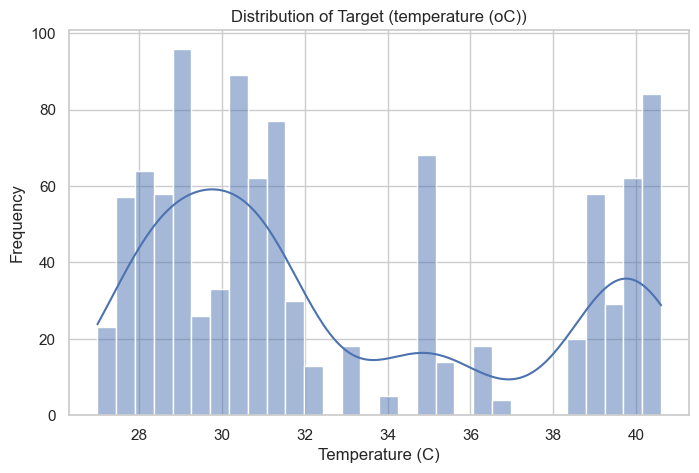

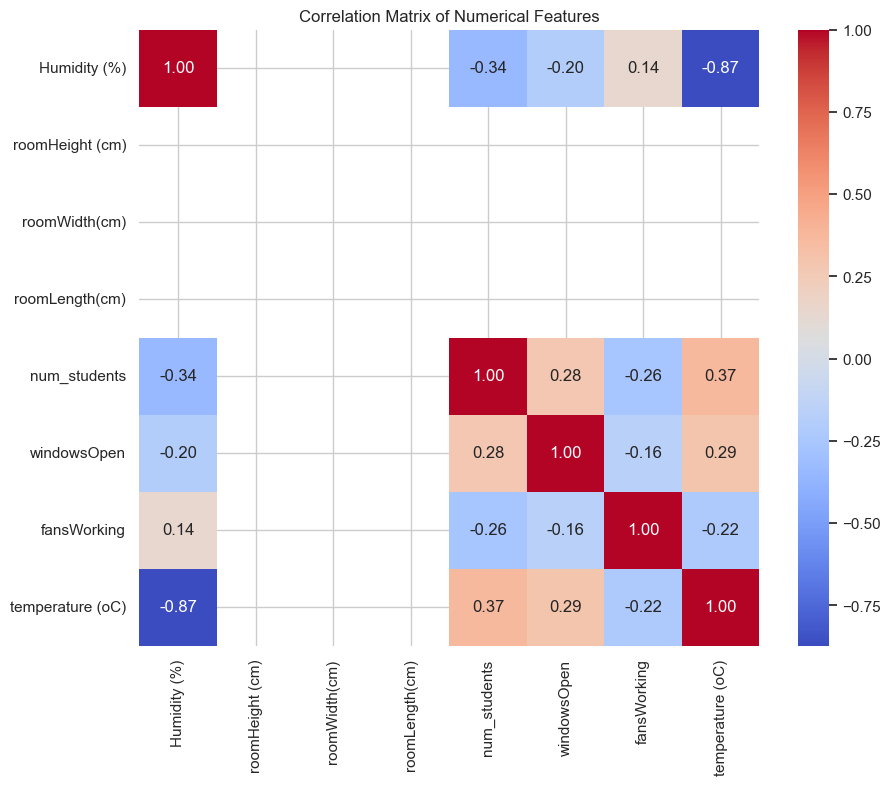

In [15]:
sns.set_theme(style='whitegrid')

# Target variable distribution
plt.figure(figsize=(8, 5))
sns.histplot(y, kde=True, bins=30)
plt.title('Distribution of Target (temperature (oC))')
plt.xlabel('Temperature (C)')
plt.ylabel('Frequency')
plt.show()

# Correlation heatmap for numerical features
plt.figure(figsize=(10, 8))
corr_matrix = data[list(num_cols) + [target_col]].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

In [16]:
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regression model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

print("Model initialized successfully.")

Model initialized successfully.


In [17]:
# Train Random Forest
print("\nTraining Random Forest model...")
rf_model.fit(X_train_scaled, y_train)
print("Random Forest training complete.")


Training Random Forest model...
Random Forest training complete.


Model Evaluation Performance:



,Model,MSE,MAE,R2 Score
0,Random Forest,1.165337,0.60797,0.945202


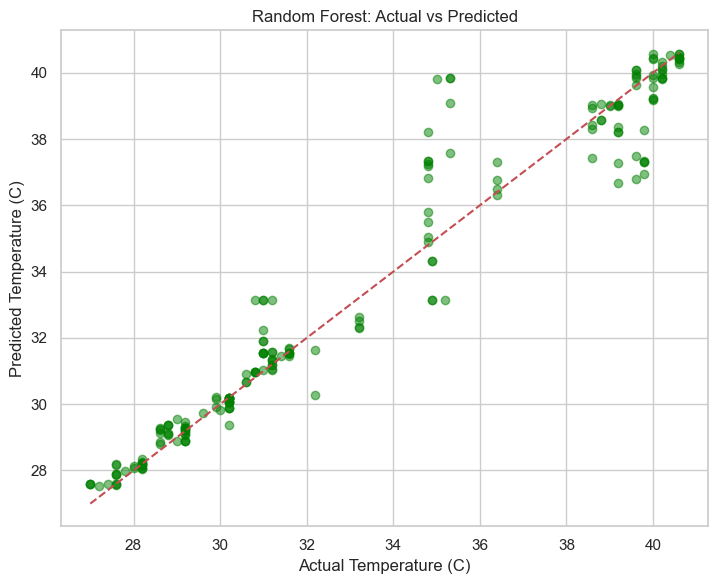

In [18]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Generate predictions
rf_preds = rf_model.predict(X_test_scaled)

# Calculate evaluation metrics
results = pd.DataFrame({
    'Model': ['Random Forest'],
    'MSE': [
        mean_squared_error(y_test, rf_preds)
    ],
    'MAE': [
        mean_absolute_error(y_test, rf_preds)
    ],
    'R2 Score': [
        r2_score(y_test, rf_preds)
    ]
})
print("Model Evaluation Performance:\n")
display(results)

# Plotting predictions vs actual values
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 2)
plt.scatter(y_test, rf_preds, alpha=0.5, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Random Forest: Actual vs Predicted')
plt.xlabel('Actual Temperature (C)')
plt.ylabel('Predicted Temperature (C)')

plt.tight_layout()
plt.show()

In [21]:
sample_input = np.zeros((1, 62))  # Create array of 62 zeros

# Then assign your known values by index
sample_input[0, 0]  = 70    # Humidity
sample_input[0, 1]  = 379   # roomHeight (cm)
sample_input[0, 2]  = 760   # roomWidth (cm)
sample_input[0, 3]  = 1516  # roomLength (cm)
sample_input[0, 4]  = 65    # num_students
sample_input[0, 5]  = 8     # windowsOpen
sample_input[0, 6]  = 4     # fansWorking

prediction = rf_model.predict(sample_input)

print("Predicted Classroom Temperature:", prediction[0], "°C")

Predicted Classroom Temperature: 29.327999999999943 °C
